In [1]:
# Question: Bitcoin market is currently in which risk matter (classified by regimes)?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("btcusd_1-min_data.csv")

df["date"] = pd.to_datetime(df["Timestamp"], unit="s")
df = df.set_index("date").sort_index()

btc_daily = df["Close"].resample("1D").last().dropna().to_frame()

btc_daily["return_pct"] = btc_daily["Close"].pct_change() * 100
btc_daily = btc_daily.dropna()

data = btc_daily.copy()

In [7]:
# Create rolling volatility

data["rolling_vol_30d"] = data["return_pct"].rolling(30).std()

data["rolling_vol_60d"] = data["return_pct"].rolling(60).std()

In [9]:
# Rolling historical VaR / ES

def historical_var(x, alpha=0.05):
    return np.quantile(x, alpha)

def historical_es(x, alpha=0.05):
    var = np.quantile(x, alpha)
    tail = x[x <= var]
    if len(tail) == 0:
        return np.nan
    return tail.mean()

data["hist_var_5_250d"] = data["return_pct"].rolling(250).apply(
    lambda x: historical_var(x, 0.05),
    raw=False
)

data["hist_es_5_250d"] = data["return_pct"].rolling(250).apply(
    lambda x: historical_es(x, 0.05),
    raw=False
)

In [11]:
regime_df = data.dropna().copy()

In [13]:
# Convert metrics into risk scores (because VaR/ES is negative)

regime_df["vol_score"] = regime_df["rolling_vol_30d"]
regime_df["var_score"] = -regime_df["hist_var_5_250d"]
regime_df["es_score"] = -regime_df["hist_es_5_250d"]

In [15]:
# Percentile Rank

regime_df["vol_pct"] = regime_df["vol_score"].rank(pct=True)
regime_df["var_pct"] = regime_df["var_score"].rank(pct=True)
regime_df["es_pct"] = regime_df["es_score"].rank(pct=True)

In [17]:
# Composite risk score (weighted average)

regime_df["risk_score"] = (
    0.4 * regime_df["vol_pct"] +
    0.3 * regime_df["var_pct"] +
    0.3 * regime_df["es_pct"]
)

In [19]:
# Define regimes (4 levels)

def classify_regime(score):
    if score < 0.50:
        return "Low Risk"
    elif score < 0.80:
        return "Moderate Risk"
    elif score < 0.95:
        return "High Risk"
    else:
        return "Extreme Risk"

regime_df["risk_regime"] = regime_df["risk_score"].apply(classify_regime)

In [21]:
# Encode regimes (for plotting)

regime_map = {
    "Low Risk": 1,
    "Moderate Risk": 2,
    "High Risk": 3,
    "Extreme Risk": 4
}

regime_df["regime_code"] = regime_df["risk_regime"].map(regime_map)

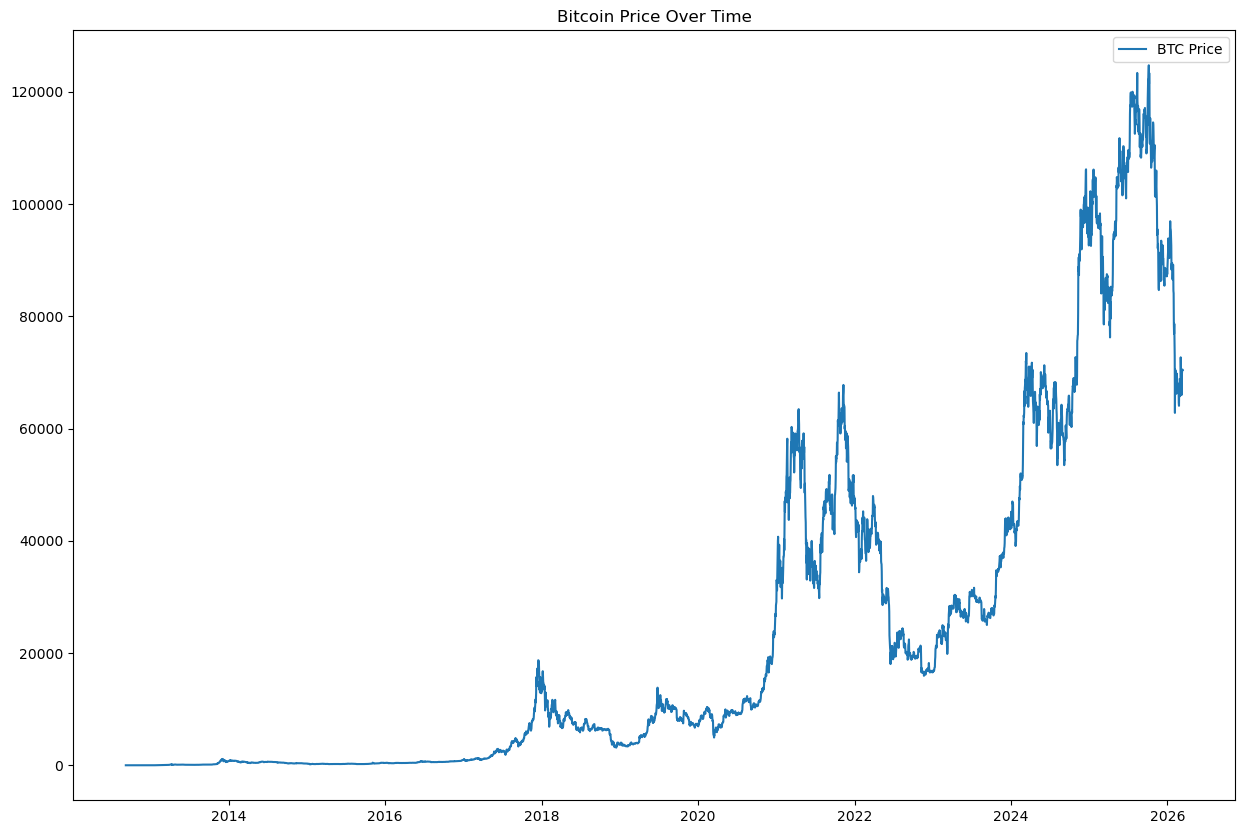

In [25]:
# Plot price + regimes

plt.figure(figsize=(15, 10))
plt.plot(regime_df.index, regime_df["Close"], label="BTC Price")
plt.title("Bitcoin Price Over Time")
plt.legend()
plt.show()

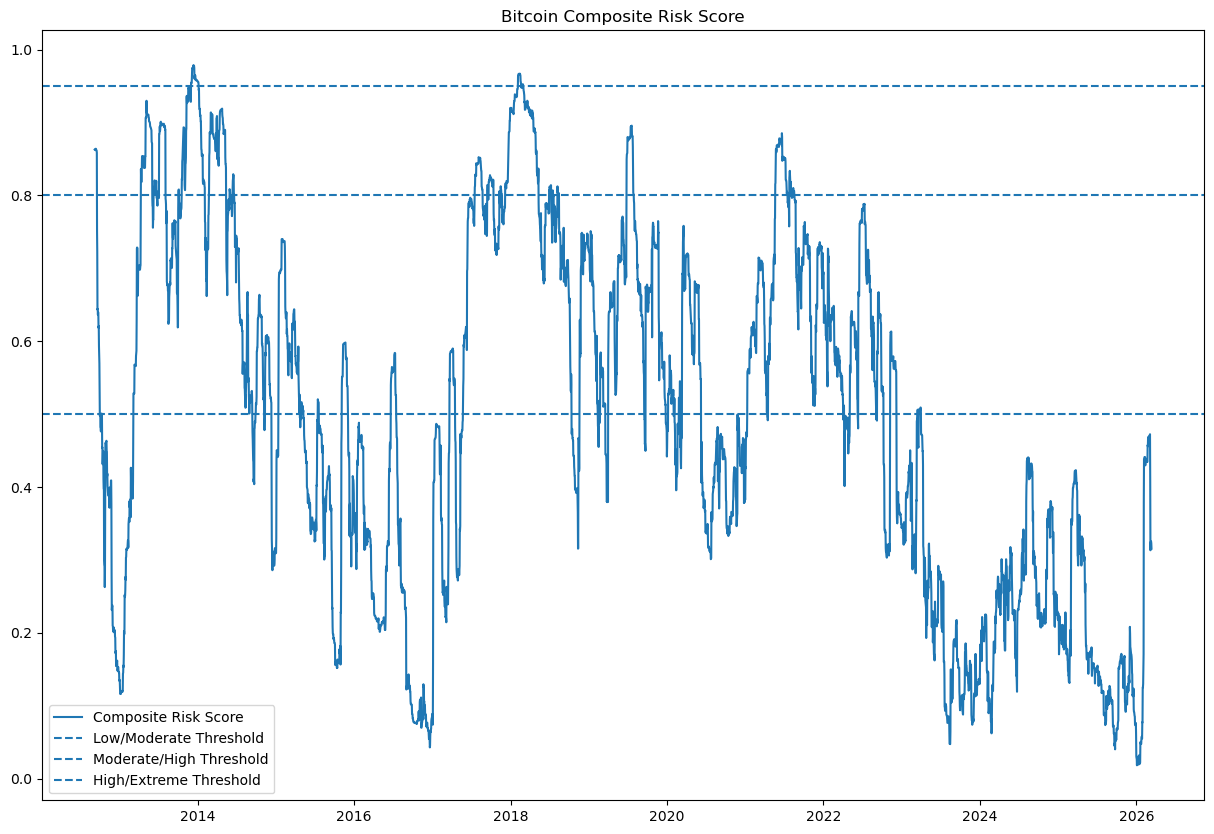

In [29]:
# Plot composite risk score

plt.figure(figsize=(15, 10))
plt.plot(regime_df.index, regime_df["risk_score"], label="Composite Risk Score")
plt.axhline(0.50, linestyle="--", label="Low/Moderate Threshold")
plt.axhline(0.80, linestyle="--", label="Moderate/High Threshold")
plt.axhline(0.95, linestyle="--", label="High/Extreme Threshold")
plt.title("Bitcoin Composite Risk Score")
plt.legend()
plt.show()

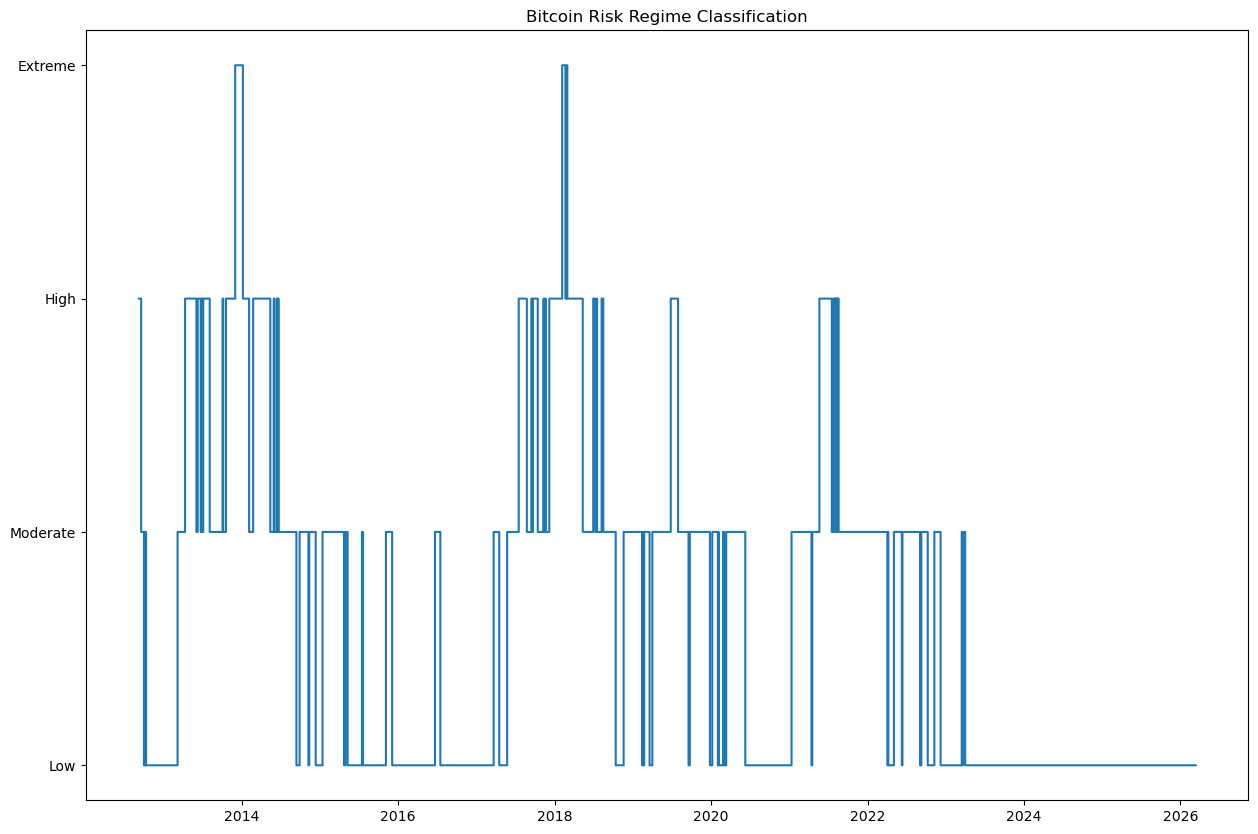

In [33]:
# Plot regime code over time

plt.figure(figsize=(15, 10))
plt.plot(regime_df.index, regime_df["regime_code"], drawstyle="steps-post")
plt.yticks([1, 2, 3, 4], ["Low", "Moderate", "High", "Extreme"])
plt.title("Bitcoin Risk Regime Classification")
plt.show()

In [35]:
# Regime counts

regime_counts = regime_df["risk_regime"].value_counts().reset_index()
regime_counts.columns = ["Regime", "Count"]

regime_counts

,Regime,Count
0,Low Risk,2446
1,Moderate Risk,1820
2,High Risk,616
3,Extreme Risk,54


In [37]:
# Regime transition intuition

latest_row = regime_df.iloc[-1][[
    "Close",
    "rolling_vol_30d",
    "hist_var_5_250d",
    "hist_es_5_250d",
    "risk_score",
    "risk_regime"
]]

latest_row

Close               70451.0
rolling_vol_30d    2.683711
hist_var_5_250d   -3.814686
hist_es_5_250d     -5.65056
risk_score         0.315519
risk_regime        Low Risk
Name: 2026-03-13 00:00:00, dtype: object

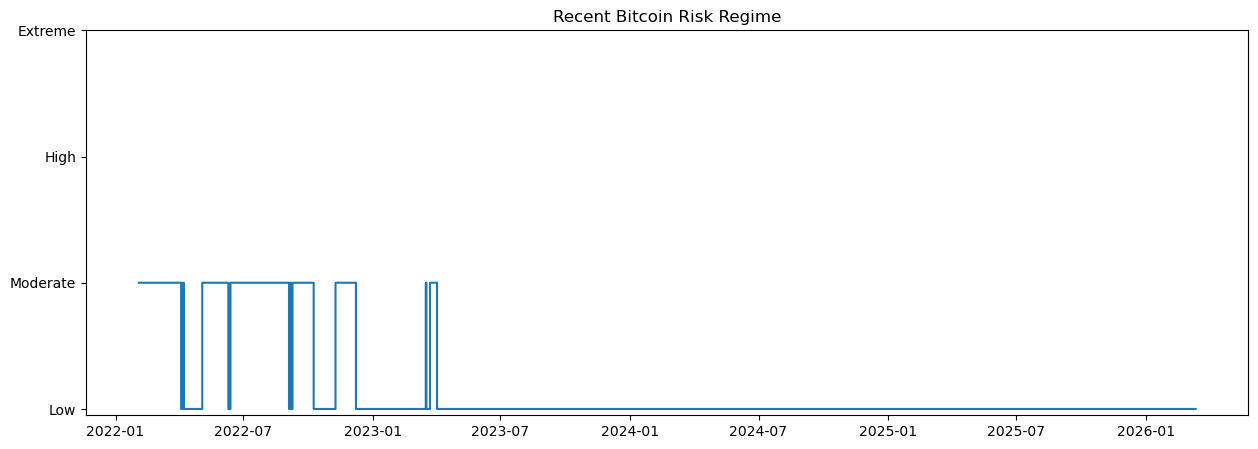

In [43]:
# Recent regime window

recent = regime_df.tail(1500)

plt.figure(figsize=(15, 5))
plt.plot(recent.index, recent["regime_code"], drawstyle="steps-post")
plt.yticks([1, 2, 3, 4], ["Low", "Moderate", "High", "Extreme"])
plt.title("Recent Bitcoin Risk Regime")
plt.show()

In [ ]:
# Color regime periods on price chart

plt.figure(figsize=(15, 7))
plt.plot(regime_df.index, regime_df["Close"], color="black", linewidth=1)

for regime, code in regime_map.items():
    subset = regime_df[regime_df["risk_regime"] == regime]
    plt.scatter(subset.index, subset["Close"], s=5, label=regime)

plt.title("Bitcoin Price with Risk Regime Overlay")
plt.legend()
plt.show()